In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

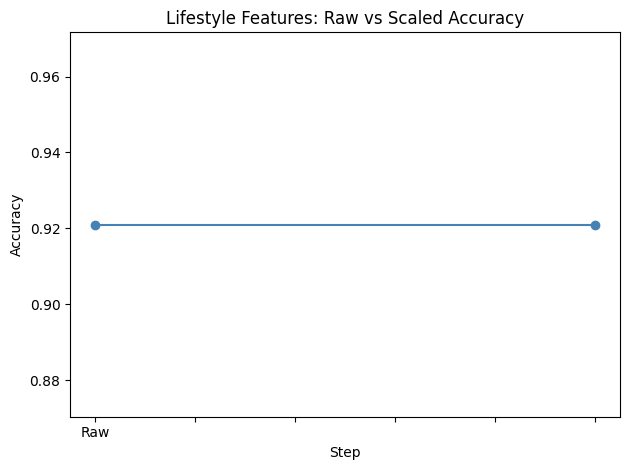

RQ3 Results
  Step  Accuracy
   Raw     0.921
Scaled     0.921
RQ3 Complete! Files saved: RQ3_table.csv, RQ3_figure.pdf


In [14]:
# ============================================================
# RQ2: How do key lifestyle factors (sleep duration, physical
# activity, screen time, and social interaction) influence the
# predictive performance of mental health models?
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

# --- Step 1: Load Dataset ---
df = pd.read_csv("/kaggle/input/datasets/dhrubangtalukdar/global-mental-health-and-lifestyle-survey-dataset/mental_health.csv")

# --- Step 2: Encode Categorical Columns ---
cat_cols = df.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# --- Step 3: Lifestyle Features ---
lifestyle_cols = [
    "Sleep_Hours_Night",
    "Exercise_Per_Week",
    "Screen_Time_Hours_Day",
    "Social_Support"
]

X = df[lifestyle_cols]
y = df["Has_Mental_Health_Issue"]

results = []

# --- Step 4: Raw (Unscaled) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = XGBClassifier(eval_metric='logloss', random_state=42)
model.fit(X_train, y_train)
acc = accuracy_score(y_test, model.predict(X_test))
results.append(["Raw", round(acc, 4)])

# --- Step 5: Scaled ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train_s, X_test_s, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
model.fit(X_train_s, y_train)
acc = accuracy_score(y_test, model.predict(X_test_s))
results.append(["Scaled", round(acc, 4)])

# --- Step 6: Save Table ---
df_pre = pd.DataFrame(results, columns=["Step", "Accuracy"])
df_pre.to_csv("RQ3_table.csv", index=False)

# --- Step 7: Plot ---
df_pre.plot(x="Step", y="Accuracy", marker='o', legend=False, color='steelblue')
plt.title("Lifestyle Features: Raw vs Scaled Accuracy")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.savefig("RQ3_figure.pdf")
plt.show()

# --- Step 8: Print Results ---
print("=" * 40)
print("RQ3 Results")
print("=" * 40)
print(df_pre.to_string(index=False))
print("=" * 40)
print("RQ3 Complete! Files saved: RQ3_table.csv, RQ3_figure.pdf")